<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Class-Code-Practice/blob/main/Ostad_AI_Engineering_classcode_Practice_11(Introduction%20to%20Linear%20Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#**Introduction to Linear Regression**

Linear Regression is one of the simplest algorithms in machine learning.  
It tries to model the relationship between:
- **Independent variable(s) (X)** → input/features  
- **Dependent variable (y)** → output/target  

💡 The idea is to fit a straight line (in 2D) or a hyperplane (in higher dimensions) that best predicts `y` from `X`.


![](https://media.geeksforgeeks.org/wp-content/uploads/20251212171555234007/introduction_to_linear_reg.webp)

# **Ridge and Lasso Regression**

1. Ridge and Lasso regression are regularization techniques that **Enhance Linear Regression** by adding a penalty term to the loss function, **preventing overfitting and managing multicollinearity.**

2. Ridge (L2) **shrinks coefficients toward zero** but keeps all features, while Lasso (L1) **shrinks some coefficients to exactly zero**, performing automatic feature selection

![](https://i0.wp.com/thaddeus-segura.com/wp-content/uploads/2020/09/reg-intro.png?resize=525%2C288&ssl=1)

![](https://miro.medium.com/1*er-t1ZVTdNn1DmiccvHDgQ.png)

# **Example With Codes**

###  **1.Importing libraries**


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### **2.Creating simple dataset (Study Hours vs Marks)**

In [4]:
np.random.seed(42)
X = np.random.rand(50, 1) * 10   # study hours (0–10)
y = 5 + 2 * X + np.random.randn(50, 1) * 2  # marks with noise
df = pd.DataFrame({
    'StudyHours': X.flatten(),
    'Marks': y.flatten()
})

print(df.head())

   StudyHours      Marks
0    3.745401  13.967736
1    9.507143  24.357023
2    7.319939  19.408582
3    5.986585  16.370962
4    1.560186   5.163329


### **3.Visualizing data**

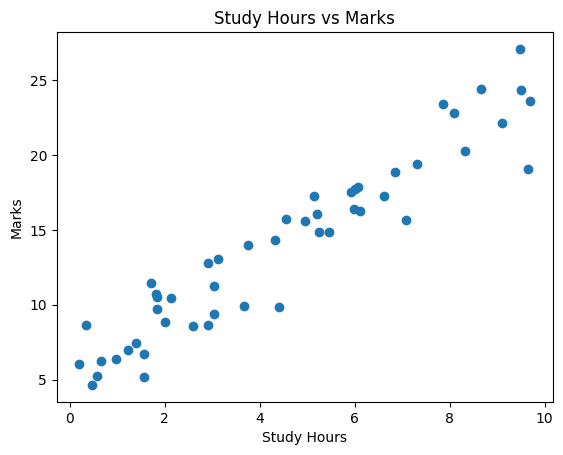

In [5]:
plt.scatter(df['StudyHours'], df['Marks'])
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Study Hours vs Marks')
plt.show()

### **4. Train-test split**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### **5. Linear Regression model**

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)  # we found optimal  m here

y_pred = model.predict(X_test)

# Print coefficients
print("Slope (m):", model.coef_[0][0])
print("Intercept (b):", model.intercept_[0])

Slope (m): 1.9447378627984213
Intercept (b): 5.247342023154038


### **6. Evaluation**

In [10]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 3.185218649865341
R2 Score: 0.8631494906196248


### **7.Plot regressioning line**

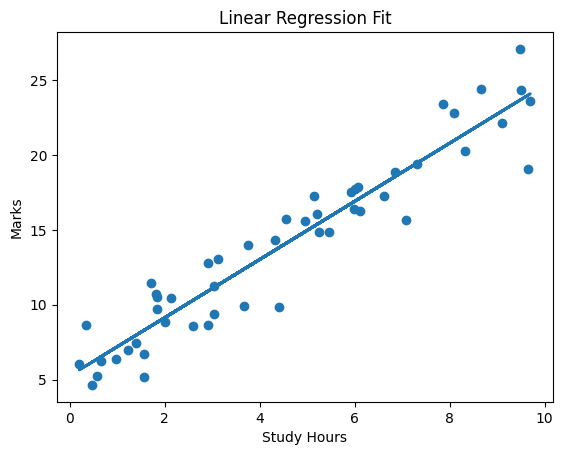

In [16]:
plt.scatter(X, y)
plt.plot(X, model.predict(X), linewidth=2)
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Linear Regression Fit')
plt.show()


## **8. Ridge Regression**

Ridge Regression:

Ridge MSE: 3.1900312383743556


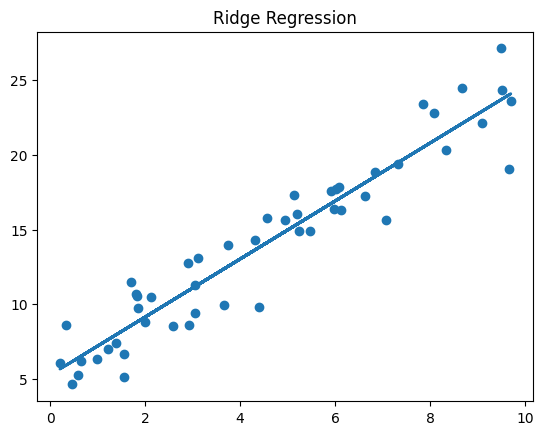

In [27]:
ridge = Ridge(alpha=1.0) # lamda / alpha
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)


print("Ridge Regression:")
print("="*17+"\n")

print("Ridge MSE:", mean_squared_error(y_test, ridge_pred))

# Plot Ridge
plt.scatter(X, y)
plt.plot(X, ridge.predict(X), linewidth=2)
plt.title('Ridge Regression')
plt.show()

### **9. Lasso Regression**

Lasso Regression:

Lasso MSE: 3.248494441337249


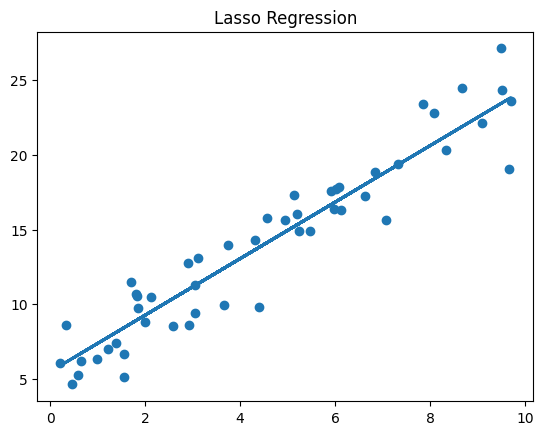

In [26]:
# 9. Lasso Regression
lasso = Lasso(alpha=0.5)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)
print("Lasso Regression:")
print("="*17+"\n")

print("Lasso MSE:", mean_squared_error(y_test, lasso_pred))
# Plot Lasso
plt.scatter(X, y)
plt.plot(X, lasso.predict(X), linewidth=2)
plt.title('Lasso Regression')
plt.show()


### **10.Comparing Coefficien**


In [28]:
print("\n--- Coefficient Comparison ---")
print("Linear:", model.coef_)
print("Ridge:", ridge.coef_)
print("Lasso:", lasso.coef_)


--- Coefficient Comparison ---
Linear: [[1.94473786]]
Ridge: [1.93935094]
Lasso: [1.88918397]


### **11. Simple Prediction Example**

In [29]:

hours = np.array([[4]])
prediction = model.predict(hours)

print(f"\nPredicted marks for 4 hours study: {prediction[0][0]:.2f}")
y = 1.94*X + 5.24
marks = 1.94*hours + 5.24


Predicted marks for 4 hours study: 13.03
